In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from matplotlib.animation import FuncAnimation
import random

class IsingModel:
    """
    A class to simulate the 2D Ising Model using the Metropolis algorithm.
    """

    def __init__(self, N,B=0, J=0.1,T=8, initial_state='random'):
        """
        Initializes the Ising model.

        Args:
            N (int): The size of the N inputs N square lattice.
            J (float): The exchange coupling constant. J > 0 for ferromagnetic.
            initial_state (str): 'random' for a random initial spin configuration,
                                 'up' for all spins initialized to +1.
        """
        self.N = N
        self.J = J
        self.T=T
        self.B=B
        self.config = self._initialize_lattice(initial_state)
        self.energies = []  # To store system energy at each step
        self.magnetizations = [] # To store system magnetization at each step

    def _initialize_lattice(self, initial_state):
        """
        Initializes the N inputs N spin lattice.

        Args:
            initial_state (str): 'random' or 'up'.

        Returns:
            np.ndarray: The initialized spin configuration (+1 or -1).
        """
        size=[]
        for i in range (2):
            size.append(self.N)
        size=tuple(size)
        if initial_state == 'random':
            # Randomly initialize spins to +1 or -1
            return np.random.choice([-1, 1], size)
        elif initial_state == 'up':
            # Initialize all spins to +1 (ferromagnetic state)
            return np.ones(size, dtype=int)
        else:
            raise ValueError("initial_state must be 'random' or 'up'")

    def _calculate_energy_change(self, i, j):
        """
        Calculates the change in energy if the spin at (i, j) is flipped.
        Uses periodic boundary conditions.

        Args:
            i (int): Row index of the spin.
            j (int): Column index of the spin.

        Returns:
            float: The change in energy (dE) if the spin is flipped.
        """
        spin = self.config[i, j]

        # Calculate sum of nearest neighbors using periodic boundary conditions
        # (i+1)%N, (i-1+N)%N, (j+1)%N, (j-1+N)%N handle wrapping around
        neighbor_sum = (
            self.config[(i + 1) % self.N, j] +  # Down
            self.config[(i - 1 + self.N) % self.N, j] +  # Up
            self.config[i, (j + 1) % self.N] +  # Right
            self.config[i, (j - 1 + self.N) % self.N]    # Left
        )

        # The energy change for flipping a spin is 2 * J * current_spin * sum_of_neighbors
        # This is because the original interaction was -J * spin * neighbor_sum,
        # and after flipping it becomes -J * (-spin) * neighbor_sum = J * spin * neighbor_sum.
        # So, dE = (J * spin * neighbor_sum) - (-J * spin * neighbor_sum) = 2 * J * spin * neighbor_sum
        dE = 2 * self.J * spin * neighbor_sum + 2*self.B*spin
        return dE

    def _monte_carlo_step(self, temperature):
        """
        Performs one Monte Carlo step using the Metropolis algorithm.
        In each step, N*N attempts are made to flip a randomly chosen spin.

        Args:
            temperature (float): The temperature of the system.
        """
        temperature=self.T
        if temperature <= 0: # Avoid division by zero or negative temperature issues
            temperature = 1e-9 # Small positive value for very low temperatures

        for _ in range(self.N * self.N): # N*N attempts per MC step
            # Choose a random spin
            i, j = random.randint(0, self.N - 1), random.randint(0, self.N - 1)

            dE = self._calculate_energy_change(i, j)

            # Metropolis criterion
            if dE <= 0:
                # Accept if energy decreases or stays the same
                self.config[i, j] *= -1
            else:
                # Accept with probability exp(-dE / (k_B * T)), k_B is set to 1
                if random.random() < np.exp(-dE / temperature):
                    self.config[i, j] *= -1

    def calculate_total_energy(self):
        """
        Calculates the total energy of the current configuration.

        Returns:
            float: The total energy of the system.
        """
        energy = 0
        for i in range(self.N):
            for j in range(self.N):
                spin = self.config[i, j]
                # Sum of neighbors, avoiding double counting by only considering right and down neighbors
                neighbor_sum = (
                    self.config[(i + 1) % self.N, j] +
                    self.config[i, (j + 1) % self.N]
                )
                energy += -self.J * spin * neighbor_sum - self.B*spin
        return energy

    def calculate_magnetization(self):
        """
        Calculates the total magnetization of the current configuration.

        Returns:
            float: The total magnetization of the system.
        """
        return np.sum(self.config)

    def simulate(self, mc_steps, temperature, equilibration_steps=0):
        """
        Runs the Monte Carlo simulation.

        Args:
            mc_steps (int): Number of Monte Carlo steps to run after equilibration.
            temperature (float): The temperature for the simulation.
            equilibration_steps (int): Number of steps to run for equilibration
                                       before collecting data.
        """
        temperature=self.T
        #print(f"Starting simulation at T = {temperature}...")
        # Equilibration phase
        for step in range(equilibration_steps):
            self._monte_carlo_step(temperature)
            if (step + 1) % (equilibration_steps // 10) == 0:
                pass
                #print(f"Equilibration: {step + 1}/{equilibration_steps} steps completed.")

        # Data collection phase
        self.energies = []
        self.magnetizations = []
        for step in range(mc_steps):
            self._monte_carlo_step(temperature)
            self.energies.append(self.calculate_total_energy())
            self.magnetizations.append(self.calculate_magnetization())
            if (step + 1) % (mc_steps // 10) == 0:
                pass
                #print(f"Simulation: {step + 1}/{mc_steps} steps completed.")
        #print("Simulation finished.")

    def animate_simulation(self, total_steps, temperature, interval_ms=50):
        """
        Animates the Ising model simulation.

        Args:
            total_steps (int): Total number of Monte Carlo steps for the animation.
            temperature (float): The temperature for the simulation.
            interval_ms (int): Delay between frames in milliseconds.
        """
        temperature=self.T
        if temperature <= 0:
            temperature = 1e-9

        fig, ax = plt.subplots(figsize=(6, 6))
        img = ax.imshow(self.config, cmap='coolwarm', vmin=-1, vmax=1)
        ax.set_title(f"Ising Model Simulation (T = {temperature:.2f})")
        ax.set_xticks([])
        ax.set_yticks([])

        def update(frame):
            self._monte_carlo_step(temperature)
            img.set_array(self.config)
            ax.set_title(f"Ising Model Simulation (T = {temperature:.2f}, Step: {frame+1})")
            return [img]

        print(f"Preparing animation for {total_steps} steps at T = {temperature}...")
        ani = FuncAnimation(fig, update, frames=total_steps, blit=True, interval=interval_ms)
        plt.show()
        print("Animation completed.")

    def plot_observables(self):
        """
        Plots the energy and magnetization per spin over Monte Carlo steps.
        """
        if not self.energies or not self.magnetizations:
            print("No simulation data to plot. Run simulate() first.")
            return

        steps = np.arange(len(self.energies))
        num_spins = self.N * self.N

        fig, axes = plt.subplots(2, 1, figsize=(10, 8))

        # Plot Energy per spin
        axes[0].plot(steps, np.array(self.energies) / num_spins, label='Energy per Spin')
        axes[0].set_xlabel("Monte Carlo Steps")
        axes[0].set_ylabel("Energy / Spin")
        axes[0].set_title("Energy per Spin vs. Monte Carlo Steps")
        axes[0].grid(True)
        axes[0].legend()

        # Plot Magnetization per spin
        axes[1].plot(steps, np.array(self.magnetizations) / num_spins, label='Magnetization per Spin', color='orange')
        axes[1].set_xlabel("Monte Carlo Steps")
        axes[1].set_ylabel("Magnetization / Spin")
        axes[1].set_title("Magnetization per Spin vs. Monte Carlo Steps")
        axes[1].grid(True)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

# --- Main execution ---
if __name__ == "__main__":
    # Parameters for the simulation
    LATTICE_SIZE = 4       # N x N lattice
    TEMP_HIGH = 2.5         # High temperature (disordered phase)
    TEMP_LOW = 0.5          # Low temperature (ordered phase)
    MC_STEPS_SIM = 50     # Monte Carlo steps for data collection
    EQUILIBRATION_STEPS = 500 # Steps to reach equilibrium before collecting data
    MC_STEPS_ANIM = 300   # Monte Carlo steps for animation
    '''now lets us get the data from ising model so we define m as magnetizetion
     and vary applied magnetic field and the interaction between neighbouring spins'''

    mag=[]
    inputs=[]
    for i in range(7):
        for j in range(1,40):
            pass
            model=IsingModel(N=LATTICE_SIZE,B=(i/2),J=0.5,T=(j/2),initial_state='random')
            model.simulate(MC_STEPS_SIM,TEMP_HIGH,EQUILIBRATION_STEPS)
            avg_mag= (np.sum(model.magnetizations))/(LATTICE_SIZE*MC_STEPS_SIM*LATTICE_SIZE)
            inputs.append([(j/2),(i/2)])
            print(f"running at magnetic field={(i/2)} and temperature = {j/2}")
            if avg_mag>=0.2:
                mag.append(1)
            else:
                mag.append(0)
    print(mag)
    mag=np.array(mag)
    inputs=np.array(inputs)
    print(inputs)
    # --- Simulate at a high temperature (disordered state) ---
    '''print("\n--- Simulating at High Temperature (T = 2.5) ---")
    ising_high_temp = IsingModel(N=LATTICE_SIZE, initial_state='random')
    ising_high_temp.simulate(MC_STEPS_SIM, TEMP_HIGH, EQUILIBRATION_STEPS)
    avg_mag= (np.sum(ising_high_temp.magnetizations))/(LATTICE_SIZE*MC_STEPS_SIM)
    print("AVG MAG=",avg_mag)
    print(ising_high_temp.config)
    print(np.sum(ising_high_temp.config))'''
    phase=svm.SVC(kernel='rbf',gamma=1,C=1)
    X_train, X_test, y_train, y_test = train_test_split(inputs,mag, test_size=0.3, random_state=42)
    phase.fit(X_train,y_train)
    y_pred = phase.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# Plot decision boundary
    def plot_decision_boundary(inputs, mag, model):

    # Create mesh
        h = 0.02  # step size
        x_min, x_max = inputs[:, 0].min() - 1, inputs[:, 0].max() + 1
        y_min, y_max = inputs[:, 1].min() - 1, inputs[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict for each point in mesh
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

    # Plot
        plt.contourf(xx, yy, Z, alpha=0.8)
        plt.scatter(inputs[:, 0], inputs[:, 1], c=mag, edgecolors='k')
        plt.title('Non-linear SVM Decision Boundary')
        plt.xlabel("TEMPERATURE")
        plt.ylabel("APPLIED MAGNETIC FIELD")
        plt.show()

    plot_decision_boundary(inputs, mag, phase)

running at magnetic field=0.0 and temperature = 0.5
running at magnetic field=0.0 and temperature = 1.0
running at magnetic field=0.0 and temperature = 1.5
running at magnetic field=0.0 and temperature = 2.0
running at magnetic field=0.0 and temperature = 2.5
running at magnetic field=0.0 and temperature = 3.0
running at magnetic field=0.0 and temperature = 3.5
running at magnetic field=0.0 and temperature = 4.0
running at magnetic field=0.0 and temperature = 4.5
running at magnetic field=0.0 and temperature = 5.0
running at magnetic field=0.0 and temperature = 5.5
running at magnetic field=0.0 and temperature = 6.0
running at magnetic field=0.0 and temperature = 6.5
running at magnetic field=0.0 and temperature = 7.0
running at magnetic field=0.0 and temperature = 7.5
running at magnetic field=0.0 and temperature = 8.0
running at magnetic field=0.0 and temperature = 8.5
running at magnetic field=0.0 and temperature = 9.0
running at magnetic field=0.0 and temperature = 9.5
running at m

Running at B=0.0, T=0.5, Mag=0.196, Cv=0.168, Chi=3585304113722341888.000
Running at B=0.0, T=1.0, Mag=0.886, Cv=1.126, Chi=1012464186057186560.000
Running at B=0.0, T=1.5, Mag=0.178, Cv=0.451, Chi=7939111020782088192.000
Running at B=0.0, T=2.0, Mag=0.075, Cv=0.138, Chi=1230020757419834880.000
Running at B=0.0, T=2.5, Mag=0.076, Cv=0.104, Chi=982405792104213760.000
Running at B=0.0, T=3.0, Mag=0.071, Cv=0.048, Chi=663887388455990656.000
Running at B=0.0, T=3.5, Mag=0.079, Cv=0.050, Chi=710826369308797056.000
Running at B=0.0, T=4.0, Mag=0.069, Cv=0.031, Chi=376013129244946560.000
Running at B=0.0, T=4.5, Mag=0.066, Cv=0.025, Chi=331570692740390976.000
Running at B=0.0, T=5.0, Mag=0.062, Cv=0.016, Chi=319642934059000512.000
Running at B=0.0, T=5.5, Mag=0.072, Cv=0.014, Chi=403097809654623680.000
Running at B=0.0, T=6.0, Mag=0.063, Cv=0.015, Chi=259259058668166784.000
Running at B=0.0, T=6.5, Mag=0.068, Cv=0.014, Chi=316917366493737024.000
Running at B=0.0, T=7.0, Mag=0.060, Cv=0.010, C

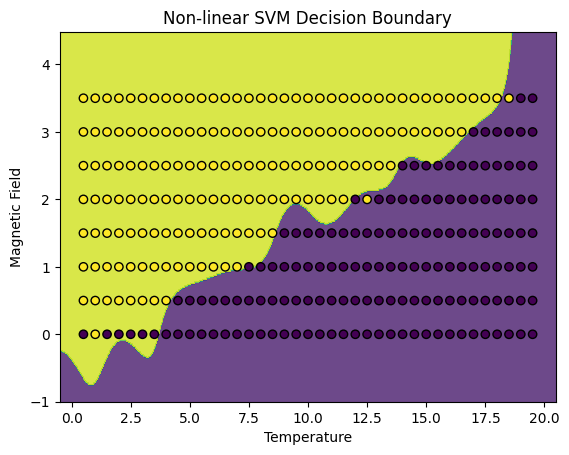

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.constants import Boltzmann
import random

class IsingModel:
    def __init__(self, N, B=0, J=0.1, T=8, initial_state='random'):
        self.N = N
        self.J = J
        self.T = T
        self.B = B
        self.config = self._initialize_lattice(initial_state)
        self.energies = []
        self.magnetizations = []

    def _initialize_lattice(self, initial_state):
        size = (self.N, self.N)
        if initial_state == 'random':
            return np.random.choice([-1, 1], size)
        elif initial_state == 'up':
            return np.ones(size, dtype=int)
        else:
            raise ValueError("initial_state must be 'random' or 'up'")

    def _calculate_energy_change(self, i, j):
        spin = self.config[i, j]
        neighbor_sum = (
            self.config[(i + 1) % self.N, j] +
            self.config[(i - 1 + self.N) % self.N, j] +
            self.config[i, (j + 1) % self.N] +
            self.config[i, (j - 1 + self.N) % self.N]
        )
        dE = 2 * self.J * spin * neighbor_sum + 2 * self.B * spin
        return dE

    def _monte_carlo_step(self, temperature):
        for _ in range(self.N * self.N):
            i, j = random.randint(0, self.N - 1), random.randint(0, self.N - 1)
            dE = self._calculate_energy_change(i, j)
            if dE <= 0 or random.random() < np.exp(-dE / temperature):
                self.config[i, j] *= -1

    def calculate_total_energy(self):
        energy = 0
        for i in range(self.N):
            for j in range(self.N):
                spin = self.config[i, j]
                neighbor_sum = (
                    self.config[(i + 1) % self.N, j] +
                    self.config[i, (j + 1) % self.N]
                )
                energy += -self.J * spin * neighbor_sum - self.B * spin
        return energy

    def calculate_magnetization(self):
        mag=np.sum(self.config)/(LATTICE_SIZE * LATTICE_SIZE)
        if self.B==0:
            q=4 #for a square lattice
            tc=(self.J*q)/Boltzmann
            if self.T>=tc:
                mag=0
        return mag

    def simulate(self, mc_steps, temperature, equilibration_steps=0):
        for _ in range(equilibration_steps):
            self._monte_carlo_step(temperature)

        self.energies = []
        self.magnetizations = []
        for _ in range(mc_steps):
            self._monte_carlo_step(temperature)
            self.energies.append(self.calculate_total_energy())
            self.magnetizations.append(self.calculate_magnetization())


def calculate_heat_capacity(energies, T, N):
    E = np.array(energies)
    mean_E = np.mean(E)
    mean_E2 = np.mean(E ** 2)
    C = (mean_E2 - mean_E ** 2) / (T ** 2)
    return C / (N * N)

def calculate_susceptibility(magnetizations, T, N):
    M = np.array(magnetizations)  # total magnetization (not normalized)
    mean_M = np.mean(M)
    mean_M2 = np.mean(M ** 2)
    chi = (mean_M2 - mean_M ** 2) / (Boltzmann * T)  # full susceptibility
    return chi / (N * N)  # per spin

def plot_decision_boundary(inputs, mag, model):
    h = 0.02
    x_min, x_max = inputs[:, 0].min() - 1, inputs[:, 0].max() + 1
    y_min, y_max = inputs[:, 1].min() - 1, inputs[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(inputs[:, 0], inputs[:, 1], c=mag, edgecolors='k')
    plt.xlabel('Temperature')
    plt.ylabel('Magnetic Field')
    plt.title('Non-linear SVM Decision Boundary')
    plt.show()

if __name__ == "__main__":
    LATTICE_SIZE = 16
    MC_STEPS_SIM = 50
    EQUILIBRATION_STEPS = 100

    features = []
    labels = []

    for i in range(8):
        for j in range(1, 40):
            T = j / 2
            B = i / 2
            model = IsingModel(N=LATTICE_SIZE, B=B, J=0.5, T=T, initial_state='random')
            model.simulate(MC_STEPS_SIM, T, EQUILIBRATION_STEPS)

            avg_mag = np.mean(np.abs(model.magnetizations))
            Cv = calculate_heat_capacity(model.energies, T, LATTICE_SIZE)
            chi = calculate_susceptibility(model.magnetizations, T, LATTICE_SIZE)

            features.append([T, B, avg_mag, Cv, chi])
            labels.append(1 if avg_mag > 0.2 else 0)

            print(f"Running at B={B}, T={T}, Mag={avg_mag:.3f}, Cv={Cv:.3f}, Chi={chi:.3f}")

    features = np.array(features)
    labels = np.array(labels)

    # Train SVM on first two features for decision boundary visualization
    X_plot = features[:, :2]
    X_train, X_test, y_train, y_test = train_test_split(X_plot, labels, test_size=0.3, random_state=42)
    clf = svm.SVC(kernel='rbf', gamma=1, C=1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"SVM Accuracy (T, B only): {accuracy_score(y_test, y_pred):.2f}")

    plot_decision_boundary(X_plot, labels, clf)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
import random

class IsingCNN(nn.Module):
    def __init__(self, L):
        super(IsingCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * (L // 4) * (L // 4), 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)  # Binary classification
        )

    def forward(self, x):
        return self.fc(self.conv(x))

class IsingDataset(Dataset):
    def __init__(self, configs, labels):
        self.X = torch.tensor(configs, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(X)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

        # Validation accuracy
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                output = model(X)
                preds = output.argmax(dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        acc = correct / total
        print(f"Validation Accuracy: {acc*100:.2f}%\n")

def predict_transition(model, data_loader, temperatures):
    probs = []
    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        for X, _ in data_loader:
            X = X.to(device)
            output = model(X)
            prob = F.softmax(output, dim=1)[:, 1]  # prob of disordered phase
            probs.append(prob.cpu().numpy())

    probs = np.concatenate(probs)
    return temperatures, probs

def create_temp_data_loaders(configs_by_T, batch_size=64):
    """
    configs_by_T: dict of { T : numpy array of configs }
    returns: list of (T, DataLoader)
    """
    loaders = []
    for T, configs in configs_by_T.items():
        dataset = IsingDataset(configs, labels=np.zeros(len(configs)))  # dummy labels
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        loaders.append((T, loader))
    return sorted(loaders)

def get_disorder_probs(model, temp_data_loaders):
    model.eval()
    device = next(model.parameters()).device

    temps, probs = [], []

    with torch.no_grad():
        for T, loader in temp_data_loaders:
            all_preds = []
            for X, _ in loader:
                X = X.to(device)
                output = model(X)
                prob = torch.softmax(output, dim=1)[:, 1]  # P(disordered)
                all_preds.append(prob.cpu().numpy())
            avg_prob = np.concatenate(all_preds).mean()
            temps.append(T)
            probs.append(avg_prob)

    return np.array(temps), np.array(probs)


def plot_phase_diagram(temps, probs):
    plt.figure(figsize=(8, 5))
    plt.plot(temps, probs, 'o-', color='crimson', label="Disordered phase probability")
    plt.axvline(2.269, color='gray', linestyle='--', label="Tc (exact)")
    plt.xlabel("Temperature (T)")
    plt.ylabel("P(disordered)")
    plt.title("Predicted Phase Diagram of 2D Ising Model")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def generate_ising_data(L, T, mc_steps=1000):
    """Generates a single Ising model configuration using Monte Carlo."""
    spins = np.random.choice([-1, 1], size=(L, L))
    for _ in range(mc_steps):
        # Pick a random spin
        x, y = random.randint(0, L-1), random.randint(0, L-1)

        # Calculate energy change if spin is flipped
        delta_E = 2 * spins[x, y] * (
            spins[(x + 1) % L, y] +
            spins[(x - 1) % L, y] +
            spins[x, (y + 1) % L] +
            spins[x, (y - 1) % L]
        )

        # Metropolis-Hastings acceptance condition
        if delta_E < 0 or random.random() < np.exp(-delta_E / T):
            spins[x, y] *= -1
    return spins

if __name__ == "__main__":
    # --- 1. Define Parameters ---
    L = 16  # Lattice size (must be divisible by 4)
    N_SAMPLES_PER_CLASS = 5000  # Number of samples for ordered/disordered classes
    N_SAMPLES_PER_TEMP = 200    # Number of samples for the final plot
    BATCH_SIZE = 64
    EPOCHS = 10


    T_ordered = 1.0
    T_disordered = 3.5


    print("Generating training and validation data...")

    ordered_configs = [generate_ising_data(L, T_ordered) for _ in range(N_SAMPLES_PER_CLASS)]
    ordered_labels = [0] * N_SAMPLES_PER_CLASS


    disordered_configs = [generate_ising_data(L, T_disordered) for _ in range(N_SAMPLES_PER_CLASS)]
    disordered_labels = [1] * N_SAMPLES_PER_CLASS


    all_configs = np.array(ordered_configs + disordered_configs)
    all_labels = np.array(ordered_labels + disordered_labels)

    full_dataset = IsingDataset(all_configs, all_labels)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    print("Data generation complete.")


    model = IsingCNN(L=L)
    train_model(model, train_loader, val_loader, epochs=EPOCHS)


    print("\nGenerating data across temperature range for phase plot...")

    temp_range = np.arange(1.5, 3.5, 0.1)
    configs_by_T = {T: [generate_ising_data(L, T) for _ in range(N_SAMPLES_PER_TEMP)] for T in temp_range}

    temp_data_loaders = create_temp_data_loaders(configs_by_T, batch_size=BATCH_SIZE)
    print("Data generation complete.")

    # --- 5. Get Predictions and Plot the Phase Diagram ---
    print("Predicting phase probabilities...")
    temps, probs = get_disorder_probs(model, temp_data_loaders)
    plot_phase_diagram(temps, probs)

Generating training and validation data...


NameError: name 'random_split' is not defined

In [ ]:
#import seaborn as sns
#import pandas as pd
from scipy.interpolate import griddata
from scipy.constants import Boltzmann

print(Boltzmann)  # Outputs: 1.380649e-23 (in J/K)

import numpy as np
import matplotlib.pyplot as plt
#from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import random

class IsingModel:
    def __init__(self, N, B=0, J=0.1, T=8, initial_state='random'):
        self.N = N
        self.J = J
        self.T = T

        self.B = B
        self.config = self._initialize_lattice(initial_state)
        self.energies = []
        self.magnetizations = []

    def _initialize_lattice(self, initial_state):
        size = (self.N, self.N)
        if initial_state == 'random':

            return np.random.choice([-1, 1], size)
        elif initial_state == 'up':
            return np.ones(size, dtype=int)
        else:
            raise ValueError("initial_state must be 'random' or 'up'")

    def _calculate_energy_change(self, i, j):
        spin = self.config[i, j]
        neighbor_sum = (
            self.config[(i + 1) % self.N, j] +
            self.config[(i - 1 + self.N) % self.N, j] +
            self.config[i, (j + 1) % self.N] +
            self.config[i, (j - 1 + self.N) % self.N]
        )
        dE = 2 * self.J * spin * neighbor_sum + 2 * self.B * spin
        return dE

    def _monte_carlo_step(self, temperature):
        for _ in range(self.N * self.N):
            i, j = random.randint(0, self.N - 1), random.randint(0, self.N - 1)
            dE = self._calculate_energy_change(i, j)
            if dE <= 0 or random.random() < np.exp(-dE / temperature):
                self.config[i, j] *= -1

    def calculate_total_energy(self):
        energy = 0
        for i in range(self.N):
            for j in range(self.N):
                spin = self.config[i, j]
                neighbor_sum = (
                    self.config[(i + 1) % self.N, j] +
                    self.config[i, (j + 1) % self.N]
                )
                energy += -self.J * spin * neighbor_sum - self.B * spin
        return energy

    def calculate_magnetization(self):
        mag=np.sum(self.config)/(LATTICE_SIZE * LATTICE_SIZE)
        if self.B==0:

            q=4 #for a square lattice
            tc=(self.J*q)/Boltzmann
            if self.T>=tc:
                mag=0


        return mag

    def simulate(self, mc_steps, temperature, equilibration_steps=0):
        for _ in range(equilibration_steps):
            self._monte_carlo_step(temperature)

        self.energies = []
        self.magnetizations = []
        for _ in range(mc_steps):
            self._monte_carlo_step(temperature)
            self.energies.append(self.calculate_total_energy())
            self.magnetizations.append(self.calculate_magnetization())


def calculate_heat_capacity(energies, T, N):
    E = np.array(energies)
    mean_E = np.mean(E)
    mean_E2 = np.mean(E ** 2)
    C = (mean_E2 - mean_E ** 2) / (T ** 2)
    return C / (N * N)

def calculate_susceptibility(magnetizations, T, N):
    M = np.array(magnetizations)
    mean_M = np.mean(np.abs(M))
    mean_M2 = np.mean(M ** 2)
    chi = (mean_M2 - mean_M ** 2) / T
    return chi / (N * N)

def plot_decision_boundary(inputs, mag, model):
    h = 0.02
    x_min, x_max = inputs[:, 0].min() - 1, inputs[:, 0].max() + 1
    y_min, y_max = inputs[:, 1].min() - 1, inputs[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(inputs[:, 0], inputs[:, 1], c=mag, edgecolors='k')
    plt.xlabel('Temperature')
    plt.ylabel('Magnetic Field')
    plt.title('Non-linear SVM Decision Boundary')
    plt.show()

if __name__ == "__main__":
    LATTICE_SIZE = 64
    MC_STEPS_SIM = 50
    EQUILIBRATION_STEPS = (LATTICE_SIZE**2)*10

    features = []
    labels = []
    t=[]
    b=[]
    xi = np.linspace(-1, 1, 200)# this is for magnetic field
    xj = np.linspace(1, 10, 200)# this is range for temperature
    for i in xi:

        for j in xj:
            T = j / 2
            B = i
            model = IsingModel(N=LATTICE_SIZE, B=B, J=0.5, T=T, initial_state='random')
            model.simulate(MC_STEPS_SIM, T, EQUILIBRATION_STEPS)

            avg_mag = np.mean(model.magnetizations)
            #Cv = calculate_heat_capacity(model.energies, T, LATTICE_SIZE)
            #chi = calculate_susceptibility(model.magnetizations, T, LATTICE_SIZE)

            t.append(T)
            b.append(B)
            labels.append(avg_mag if abs(avg_mag) > 0.05 else 0)

            if (j+1)%100==0 or True :
                print(f"Running at B={B}, T={T}, Mag={avg_mag:.3f}")
    t = np.array(t)
    b=np.array(b)
    np.savetxt('temperature_ising_heat_map.txt', t, fmt='%.9f', delimiter=' ')
    np.savetxt('magnetic_field_ising_heat_map.txt', b, fmt='%.9f', delimiter=' ')

    labels = np.array(labels)
    np.savetxt('magnetization_ising_heat_map.txt', labels, fmt='%.9f', delimiter=' ')
    #loaded_arr = np.loadtxt('myarray.txt', delimiter=' ', dtype=int)
    #loaded_t = np.loadtxt('temperature_ising_heat_map.txt', delimiter=' ')


    x1=t
    x2=b
    y=labels
    xi = np.linspace(x1.min(), x1.max(), 1000)
    xj = np.linspace(x2.min(), x2.max(), 1000)
    xi_grid, xj_grid = np.meshgrid(xi, xj)

    # Interpolate y values onto a grid
    y_grid = griddata((x1, x2), y, (xi_grid, xj_grid), method='linear')

    plt.figure(figsize=(10, 8))
    plt.imshow(y_grid, aspect='auto', cmap='coolwarm',
            extent=[x1.min(), x1.max(), x2.min(), x2.max()],
            origin='lower')
    plt.colorbar(label='Magnetization')
    plt.xlabel('T →')
    plt.ylabel('B →')
    plt.title('Heatmap of Magnetization for scattered (Temperature, Applied Magnetics Field)')
    plt.show()
    '''
    df=pd.DataFrame(labels,index=features[1],columns=features[0])
    plt.figure(figsize=(8,6))
    sns.heatmap(df,cmap="viridis")
    plt.xlabel("temperature")
    plt.ylabel("magnetic field")
    plt.show()



    # Train SVM on first two features for decision boundary visualization
    X_plot = features[:, :2]
    X_train, X_test, y_train, y_test = train_test_split(X_plot, labels, test_size=0.3, random_state=42)
    clf = svm.SVC(kernel='rbf', gamma=1, C=1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"SVM Accuracy (T, B only): {accuracy_score(y_test, y_pred):.2f}")

    plot_decision_boundary(X_plot, labels, clf)'''

1.380649e-23
Running at B=-1.0, T=0.5, Mag=-1.000
Running at B=-1.0, T=0.5226130653266332, Mag=-1.000
Running at B=-1.0, T=0.5452261306532663, Mag=-1.000
Running at B=-1.0, T=0.5678391959798995, Mag=-1.000
Running at B=-1.0, T=0.5904522613065326, Mag=-1.000
Running at B=-1.0, T=0.6130653266331658, Mag=-1.000
Running at B=-1.0, T=0.635678391959799, Mag=-1.000
Running at B=-1.0, T=0.6582914572864322, Mag=-1.000
Running at B=-1.0, T=0.6809045226130653, Mag=-1.000
Running at B=-1.0, T=0.7035175879396984, Mag=-0.999


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.constants import Boltzmann
from joblib import Parallel, delayed
import random
from tqdm import tqdm

# Set seeds
np.random.seed(42)
random.seed(42)

class IsingModel:
    def __init__(self, N, B=0, J=0.1, T=8, initial_state='random'):
        self.N = N
        self.J = J
        self.T = T
        self.B = B
        self.config = self._initialize_lattice(initial_state)
        self.energies = []
        self.magnetizations = []

    def _initialize_lattice(self, initial_state):
        size = (self.N, self.N)
        if initial_state == 'random':
            return np.random.choice([-1, 1], size)
        elif initial_state == 'up':
            return np.ones(size, dtype=int)
        else:
            raise ValueError("initial_state must be 'random' or 'up'")

    def _calculate_energy_change(self, i, j):
        spin = self.config[i, j]
        neighbor_sum = (
            self.config[(i + 1) % self.N, j] +
            self.config[(i - 1 + self.N) % self.N, j] +
            self.config[i, (j + 1) % self.N] +
            self.config[i, (j - 1 + self.N) % self.N]
        )
        dE = 2 * self.J * spin * neighbor_sum + 2 * self.B * spin
        return dE

    def _monte_carlo_step(self, temperature):
        for _ in range(self.N * self.N):
            i, j = random.randint(0, self.N - 1), random.randint(0, self.N - 1)
            dE = self._calculate_energy_change(i, j)
            if dE <= 0 or random.random() < np.exp(-dE / temperature):
                self.config[i, j] *= -1

    def calculate_total_energy(self):
        energy = 0
        for i in range(self.N):
            for j in range(self.N):
                spin = self.config[i, j]
                neighbor_sum = (
                    self.config[(i + 1) % self.N, j] +
                    self.config[i, (j + 1) % self.N]
                )
                energy += -self.J * spin * neighbor_sum - self.B * spin
        return energy

    def calculate_magnetization(self):
        mag = np.sum(self.config) / (self.N * self.N)
        if self.B == 0:
            q = 4
            tc = (self.J * q) / Boltzmann
            if self.T >= tc:
                mag = 0
        return mag

    def simulate(self, mc_steps, temperature, equilibration_steps=0):
        for _ in range(equilibration_steps):
            self._monte_carlo_step(temperature)
        self.energies = []
        self.magnetizations = []
        for _ in range(mc_steps):
            self._monte_carlo_step(temperature)
            self.energies.append(self.calculate_total_energy())
            self.magnetizations.append(self.calculate_magnetization())

# Worker function for parallel run
def run_simulation(B, T, LATTICE_SIZE, MC_STEPS_SIM, EQUILIBRATION_STEPS):
    model = IsingModel(N=LATTICE_SIZE, B=B, J=0.5, T=T)
    model.simulate(MC_STEPS_SIM, T, EQUILIBRATION_STEPS)
    avg_mag = np.mean(model.magnetizations)
    return T, B, avg_mag if abs(avg_mag) > 0.05 else 0

if __name__ == "__main__":
    LATTICE_SIZE = 64
    MC_STEPS_SIM = 50
    EQUILIBRATION_STEPS = (LATTICE_SIZE ** 2) * 10

    xi = np.linspace(-1, 1, 200)   # magnetic field
    xj = np.linspace(1, 10, 200)   # temperature
    param_list = [(B, T/2) for B in xi for T in xj]

    # Parallel execution with progress bar
    results = Parallel(n_jobs=-1)(
        delayed(run_simulation)(B, T, LATTICE_SIZE, MC_STEPS_SIM, EQUILIBRATION_STEPS)
        for B, T in tqdm(param_list, desc="Simulating (T, B) grid")
    )

    # Unpack results
    t, b, labels = zip(*results)
    t = np.array(t)
    b = np.array(b)
    labels = np.array(labels)

    np.savetxt('temperature_ising_heat_map.txt', t, fmt='%.9f', delimiter=' ')
    np.savetxt('magnetic_field_ising_heat_map.txt', b, fmt='%.9f', delimiter=' ')
    np.savetxt('magnetization_ising_heat_map.txt', labels, fmt='%.9f', delimiter=' ')

    xi_interp = np.linspace(min(t), max(t), 1000)
    xj_interp = np.linspace(min(b), max(b), 1000)
    xi_grid, xj_grid = np.meshgrid(xi_interp, xj_interp)

    y_grid = griddata((t, b), labels, (xi_grid, xj_grid), method='linear')

    plt.figure(figsize=(10, 8))
    plt.imshow(
        y_grid,
        aspect='auto',
        cmap='coolwarm',
        extent=[t.min(), t.max(), b.min(), b.max()],
        origin='lower'
    )
    plt.colorbar(label='Magnetization')
    plt.xlabel('T →')
    plt.ylabel('B →')
    plt.title('Heatmap of Magnetization (T, B)')
    plt.tight_layout()
    plt.savefig('ising_magnetization_heatmap.png', dpi=300)


Simulating (T, B) grid:   0%|          | 16/40000 [3:28:10<9554:44:20, 860.27s/it]

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from scipy.constants import Boltzmann
import matplotlib.pyplot as p
from matplotlib.animation import FuncAnimation
import random
#device config
device=torch.device('cuda' if torch.cuda.is_available else 'cpu')
'''
### Coordination Number (q) for Different Lattices in the Ising Model

The **coordination number** $$ q $$ refers to the number of nearest neighbors each site has in a lattice. This parameter is fundamental in determining the properties of the Ising model for each lattice type.

| Lattice Type                | q (Coordination Number) | Notes                                                    |
|-----------------------------|-------------------------|----------------------------------------------------------|
| 1D Linear Chain             | 2                       | Each site interacts with its two immediate neighbors[1]. |
| 2D Square Lattice           | 4                       | Each site has four neighbors (up, down, left, right)[1]. |
| 2D Triangular Lattice       | 6                       | Denser network, each site has six neighbors[1].          |
| 2D Honeycomb Lattice        | 3                       | Each site has three neighbors[1].                        |
| 3D Simple Cubic Lattice     | 6                       | Each site has six neighbors (along x, y, z axes)[1].     |
| 3D Body-Centered Cubic (BCC)| 8                       | Each site has eight nearest neighbors[1].                |
| 3D Face-Centered Cubic (FCC)| 12                      | Each site has twelve nearest neighbors[1].               |
| Cayley Tree (Bethe Lattice) | q (variable)            | Defined by branching factor, commonly q = 3 or more[2]. |

#### Key Points
- **q** is crucial for determining the critical temperature and magnetic properties of the Ising model.
- For **Cayley trees/Bethe lattices**, $$ q $$ is a parameter that can be chosen arbitrarily, often set to 3 or higher for theoretical studies[2].

This table provides the standard values of $$ q $$ for the most common lattice types used in the Ising model[1][2].

[1] https://cpb-us-w2.wpmucdn.com/u.osu.edu/dist/3/67057/files/2018/09/Ising_model_MFT-25b1klj.pdf
[2] https://theory.tifr.res.in/~tridib/ReferenceMaterial/Chapter%20Ising%20on%20Bethe%20Lattice.pdf
[3] https://en.wikipedia.org/wiki/Ising_model
[4] https://ps.uci.edu/~cyu/p115A/LectureNotes/Lecture18/html_version/lecture18.html
[5] https://stanford.edu/~jeffjar/statmech/lec4.html
[6] https://arxiv.org/html/2504.17616v1
[7] https://arxiv.org/pdf/0801.0662.pdf
[8] https://link.aps.org/doi/10.1103/PhysRevB.103.104416
[9] https://arxiv.org/pdf/0802.1101.pdf
[10] http://abel.math.umu.se/~klasm/Uppsatser/cubes.pdf
[11] https://pmc.ncbi.nlm.nih.gov/articles/PMC9954908/
[12] https://arxiv.org/pdf/1507.02453.pdf
[13] https://phas.ubc.ca/~seme/516/1D_Ising_Model.pdf
[14] https://en.wikipedia.org/wiki/Square_lattice_Ising_model
[15] https://link.aps.org/doi/10.1103/PhysRevE.87.022124
[16] https://pmc.ncbi.nlm.nih.gov/articles/PMC9689490/
[17] https://arxiv.org/abs/cond-mat/0111193
[18] https://link.aps.org/doi/10.1103/PhysRevB.25.1759
[19] https://pmc.ncbi.nlm.nih.gov/articles/PMC11593144/
[20] https://projecteuclid.org/journals/communications-in-mathematical-physics/volume-130/issue-2/Ising-model-on-the-generalized-Bruhat-Tits-tree/cmp/1104200518.pdf
'''
class IsingModel:
    def __init__(self, N, B=0, J=0.1, T=8, initial_state='random'):
        self.N = N
        self.J = J
        self.T = T
        self.B = B
        self.config = self._initialize_lattice(initial_state)
        self.energies = []
        self.magnetizations = []

    def _initialize_lattice(self, initial_state):
        size = (self.N, self.N)
        if initial_state == 'random':
            return np.random.choice([-1, 1], size)
        elif initial_state == 'up':
            return np.ones(size, dtype=int)
        else:
            raise ValueError("initial_state must be 'random' or 'up'")

    def _calculate_energy_change(self, i, j):
        spin = self.config[i, j]
        neighbor_sum = (
            self.config[(i + 1) % self.N, j] +
            self.config[(i - 1 + self.N) % self.N, j] +
            self.config[i, (j + 1) % self.N] +
            self.config[i, (j - 1 + self.N) % self.N]
        )
        dE = 2 * self.J * spin * neighbor_sum + 2 * self.B * spin
        return dE

    def _monte_carlo_step(self, temperature):
        for _ in range(self.N * self.N):
            i, j = random.randint(0, self.N - 1), random.randint(0, self.N - 1)
            dE = self._calculate_energy_change(i, j)
            if dE <= 0 or random.random() < np.exp(-dE / temperature):
                self.config[i, j] *= -1

    def calculate_total_energy(self):
        energy = 0
        for i in range(self.N):
            for j in range(self.N):
                spin = self.config[i, j]
                neighbor_sum = (
                    self.config[(i + 1) % self.N, j] +
                    self.config[i, (j + 1) % self.N]
                )
                energy += -self.J * spin * neighbor_sum - self.B * spin
        return energy

    def calculate_magnetization(self):
        mag=np.sum(self.config)/(LATTICE_SIZE * LATTICE_SIZE)
        if self.B==0:
            q=4 #for a square lattice
            tc=(self.J*q)/Boltzmann
            if self.T>=tc:
                mag=0
        return mag

    def simulate(self, mc_steps, equilibration_steps=0):
        temperature=self.T
        for _ in range(equilibration_steps):
            self._monte_carlo_step(temperature)

        self.energies = []
        self.magnetizations = []
        for _ in range(mc_steps):
            self._monte_carlo_step(temperature)
            self.energies.append(self.calculate_total_energy())
            self.magnetizations.append(self.calculate_magnetization())

    def calculate_heat_capacity(self):
        T=self.T
        energies=self.energies
        E = np.array(energies)
        mean_E = np.mean(E)
        mean_E2 = np.mean(E ** 2)
        C = (mean_E2 - mean_E ** 2) / (T ** 2)
        return C / (self.N * self.N)
    def calculate_susceptibility(self):
        T=self.T
        magnetizations=self.magnetizations
        M = np.array(magnetizations)
        mean_M = np.mean(np.abs(M))
        mean_M2 = np.mean(M ** 2)
        chi = (mean_M2 - mean_M ** 2) / T
        return chi


class neural(nn.Module):
    def __init__(self,input_size,hidden_size1,hidden_size2,num_classes):
        super(neural,self).__init__()
        self.l1=nn.Linear(input_size,hidden_size1)
        self.relu=nn.ReLU()
        self.l2=nn.Linear(hidden_size1,hidden_size2)
        self.l3=nn.Linear(hidden_size2,num_classes)

    def forward(self,x):
        out=self.l1(x)
        out=self.relu(out)
        out=self.l2(out)
        out=self.relu(out)
        out=self.l3(out)# no activation at the end for cross entropy loss
        return out

#data preparation
if __name__ == "__main__":

    LATTICE_SIZE = 128
    MC_STEPS_SIM = 100
    J=0.5
    EQUILIBRATION_STEPS = 200

    features = []
    labels = []
    range1=np.linspace(-1,0,10,endpoint=False)
    range2=np.linspace(0,1,10)
    magnetic_field_range=np.concatenate((range1,range2))#for applied magnetic field
    temperature_range=np.linspace(0.001,1,10)

    for i in magnetic_field_range:
        for j in temperature_range:
            T = j
            B = i
            model = IsingModel(N=LATTICE_SIZE, B=B, J=J, T=T, initial_state='random')
            model.simulate(MC_STEPS_SIM, EQUILIBRATION_STEPS)

            avg_mag = np.mean(np.abs(model.magnetizations))
            Cv = model.calculate_heat_capacity()
            chi = model.calculate_susceptibility()

            features.append([T, B, avg_mag, Cv, chi])
            if B==0:
                q=4 #for a square lattice
                tc=(J*q)/Boltzmann
                if T>=tc:
                    labels.append(0)
                else:
                    labels.append(1)
            else:
                labels.append(0)


            print(f"Running at B={B}, T={T}, Mag={avg_mag:.3f}, Cv={Cv:.3f}, Chi={chi:.3f}")
    input_data=np.array(features,dtype=np.float64)
    labels=np.array(labels,dtype=np.int32)
    input_data=torch.from_numpy(input_data)
    labels=torch.from_numpy(labels)
    labels=labels.detach().clone().to(torch.long)
    path="ising_data_for_lattice_"+str(LATTICE_SIZE)
    np.savetxt(path,features,fmt="%.9f",delimiter=' ')

    #hyperparameter tuning
    input_size=5
    hidden_size1=10
    hidden_size2=50
    batch_size=100
    learning_rate=0.001
    num_epoch=4
    ising_dataset=torch.utils.data.TensorDataset(input_data,labels)
    ml_model=neural(input_size,hidden_size1,hidden_size2,2)

    #loss and optimizer
    crit=nn.CrossEntropyLoss()
    optim=torch.optim.Adam(ml_model.parameters(),learning_rate)
    train_loader=torch.utils.data.DataLoader(dataset=ising_dataset,batch_size=batch_size,shuffle=True)

    #model traning
    for epoch in range(num_epoch):
        for x,y in train_loader:
            x=x.reshape(-1,5)
            x=x.to(torch.float32)


            #froward
            output=ml_model(x)
            loss=crit(output,y)

            #backward
            optim.zero_grad()
            loss.backward()
            optim.step()

    # model saving
    path_of_model='ising_ml_model_lattice'+str(LATTICE_SIZE)
    torch.save(ml_model.state_dict(),path_of_model)
    # model testing



Running at B=-1.0, T=0.001, Mag=1.000, Cv=0.000, Chi=0.000
Running at B=-1.0, T=0.112, Mag=1.000, Cv=0.000, Chi=0.000
Running at B=-1.0, T=0.223, Mag=1.000, Cv=0.000, Chi=0.000
Running at B=-1.0, T=0.334, Mag=1.000, Cv=0.000, Chi=0.000
Running at B=-1.0, T=0.445, Mag=1.000, Cv=0.001, Chi=0.000
Running at B=-1.0, T=0.556, Mag=1.000, Cv=0.002, Chi=0.000
Running at B=-1.0, T=0.667, Mag=1.000, Cv=0.016, Chi=0.000
Running at B=-1.0, T=0.778, Mag=0.999, Cv=0.018, Chi=0.000
Running at B=-1.0, T=0.889, Mag=0.998, Cv=0.042, Chi=0.000
Running at B=-1.0, T=1.0, Mag=0.995, Cv=0.087, Chi=0.000
Running at B=-0.9, T=0.001, Mag=1.000, Cv=0.000, Chi=0.000
Running at B=-0.9, T=0.112, Mag=1.000, Cv=0.000, Chi=0.000
Running at B=-0.9, T=0.223, Mag=1.000, Cv=0.000, Chi=0.000
Running at B=-0.9, T=0.334, Mag=1.000, Cv=0.000, Chi=0.000
Running at B=-0.9, T=0.445, Mag=1.000, Cv=0.000, Chi=0.000
Running at B=-0.9, T=0.556, Mag=1.000, Cv=0.004, Chi=0.000
Running at B=-0.9, T=0.667, Mag=1.000, Cv=0.016, Chi=0.000

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from scipy.constants import Boltzmann
import matplotlib.pyplot as p
import random
import os
from multiprocessing import Pool

# device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ... (Your IsingModel and neural classes remain the same) ...
class IsingModel:
    def __init__(self, N, B=0, J=0.1, T=8, initial_state='random'):
        self.N = N
        self.J = J
        self.T = T
        self.B = B
        self.config = self._initialize_lattice(initial_state)
        self.energies = []
        self.magnetizations = []

    def _initialize_lattice(self, initial_state):
        size = (self.N, self.N)
        if initial_state == 'random':
            return np.random.choice([-1, 1], size)
        elif initial_state == 'up':
            return np.ones(size, dtype=int)
        else:
            raise ValueError("initial_state must be 'random' or 'up'")

    def _calculate_energy_change(self, i, j):
        spin = self.config[i, j]
        neighbor_sum = (
            self.config[(i + 1) % self.N, j] +
            self.config[(i - 1 + self.N) % self.N, j] +
            self.config[i, (j + 1) % self.N] +
            self.config[i, (j - 1 + self.N) % self.N]
        )
        dE = 2 * self.J * spin * neighbor_sum + 2 * self.B * spin
        return dE

    def _monte_carlo_step(self, temperature):
        for _ in range(self.N * self.N):
            i, j = random.randint(0, self.N - 1), random.randint(0, self.N - 1)
            dE = self._calculate_energy_change(i, j)
            if dE <= 0 or random.random() < np.exp(-dE / temperature):
                self.config[i, j] *= -1

    def calculate_total_energy(self):
        energy = 0
        for i in range(self.N):
            for j in range(self.N):
                spin = self.config[i, j]
                neighbor_sum = (
                    self.config[(i + 1) % self.N, j] +
                    self.config[i, (j + 1) % self.N]
                )
                energy += -self.J * spin * neighbor_sum - self.B * spin
        return energy

    def calculate_magnetization(self):
        mag=np.sum(self.config)/(self.N * self.N)
        if self.B == 0:
            q=4 #for a square lattice
            tc=(self.J*q)/Boltzmann
            if self.T >= tc:
                mag=0
        return mag

    def simulate(self, mc_steps, equilibration_steps=0):
        temperature=self.T
        for _ in range(equilibration_steps):
            self._monte_carlo_step(temperature)

        self.energies = []
        self.magnetizations = []
        for _ in range(mc_steps):
            self._monte_carlo_step(temperature)
            self.energies.append(self.calculate_total_energy())
            self.magnetizations.append(self.calculate_magnetization())

    def calculate_heat_capacity(self):
        T=self.T
        energies=self.energies
        E = np.array(energies)
        mean_E = np.mean(E)
        mean_E2 = np.mean(E ** 2)
        C = (mean_E2 - mean_E ** 2) / (T ** 2)
        return C / (self.N * self.N)

    def calculate_susceptibility(self):
        T=self.T
        magnetizations=self.magnetizations
        M = np.array(magnetizations)
        mean_M = np.mean(np.abs(M))
        mean_M2 = np.mean(M ** 2)
        chi = (mean_M2 - mean_M ** 2) / T
        return chi


class neural(nn.Module):
    def __init__(self,input_size,hidden_size1,hidden_size2,num_classes):
        super(neural,self).__init__()
        self.l1=nn.Linear(input_size,hidden_size1)
        self.relu=nn.ReLU()
        self.l2=nn.Linear(hidden_size1,hidden_size2)
        self.l3=nn.Linear(hidden_size2,num_classes)

    def forward(self,x):
        out=self.l1(x)
        out=self.relu(out)
        out=self.l2(out)
        out=self.relu(out)
        out=self.l3(out)# no activation at the end for cross entropy loss
        return out


# This function will be run in parallel on each CPU core
def run_single_simulation(params):
    B, T, LATTICE_SIZE, J, MC_STEPS_SIM, EQUILIBRATION_STEPS = params

    model = IsingModel(N=LATTICE_SIZE, B=B, J=J, T=T, initial_state='random')
    model.simulate(MC_STEPS_SIM, EQUILIBRATION_STEPS)

    avg_mag = np.mean(np.abs(model.magnetizations))
    Cv = model.calculate_heat_capacity()
    chi = model.calculate_susceptibility()

    feature_data = [T, B, avg_mag, Cv, chi]

    # Labeling logic
    label = 0
    if B == 0:
        q = 4  # for a square lattice
        tc = (J * q) / Boltzmann
        if T < tc:
            label = 1

    print(f"Running at B={B:.3f}, T={T:.3f}, Mag={avg_mag:.3f}, Cv={Cv:.3f}, Chi={chi:.3f}")

    return feature_data, label

# data preparation
if __name__ == "__main__":
    LATTICE_SIZE = 32
    MC_STEPS_SIM = 50
    J = 0.5
    EQUILIBRATION_STEPS = 200

    range1 = np.linspace(-1, 0, 10, endpoint=False)
    range2 = np.linspace(0, 1, 10)
    magnetic_field_range = np.concatenate((range1, range2))
    temperature_range = np.linspace(0.001, 1, 10)

    # Create a list of all parameters for each simulation
    simulation_params = [
        (B, T, LATTICE_SIZE, J, MC_STEPS_SIM, EQUILIBRATION_STEPS)
        for B in magnetic_field_range
        for T in temperature_range
    ]

    # Use multiprocessing to run simulations in parallel
    print("Starting parallel data generation...")
    with Pool(processes=os.cpu_count()) as pool:
        # starmap applies a function with multiple arguments
        results = pool.starmap(run_single_simulation, simulation_params)

    # Collect results from the parallel processes
    features = [result[0] for result in results]
    labels = [result[1] for result in results]

    print("\nData generation complete. Proceeding with training...")

    # Data conversion to PyTorch tensors with correct dtypes
    # Use float32 for model inputs, which is standard for PyTorch
    input_data = torch.tensor(features, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.long)

    path = "ising_data_for_lattice_" + str(LATTICE_SIZE)
    np.savetxt(path, input_data.numpy(), fmt="%.9f", delimiter=' ')

    # hyperparameter tuning
    input_size = 5
    hidden_size1 = 10
    hidden_size2 = 50
    batch_size = 100
    learning_rate = 0.001
    num_epoch = 4

    ising_dataset = torch.utils.data.TensorDataset(input_data, labels)
    ml_model = neural(input_size, hidden_size1, hidden_size2, 2)

    # loss and optimizer
    crit = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(ml_model.parameters(), learning_rate)

    # Use num_workers to parallelize data loading from the dataset
    train_loader = torch.utils.data.DataLoader(
        dataset=ising_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=os.cpu_count() if os.cpu_count() else 0
    )

    # model training
    for epoch in range(num_epoch):
        for x, y in train_loader:
            # x and y are already tensors with the correct shape and dtype from DataLoader
            x = x.to(device)
            y = y.to(device)

            # forward
            output = ml_model(x)
            loss = crit(output, y)

            # backward
            optim.zero_grad()
            loss.backward()
            optim.step()

    print("Training complete.")

    # model saving
    path_of_model = 'ising_ml_model_lattice' + str(LATTICE_SIZE)
    torch.save(ml_model.state_dict(), path_of_model)

Starting parallel data generation...


TypeError: run_single_simulation() takes 1 positional argument but 6 were given

Generating training data...
Epoch 1, Loss: 17.1606
Validation Accuracy: 99.95%

Epoch 2, Loss: 1.5380
Validation Accuracy: 99.65%

Epoch 3, Loss: 0.4684
Validation Accuracy: 99.90%

Epoch 4, Loss: 0.2173
Validation Accuracy: 99.90%

Epoch 5, Loss: 0.1043
Validation Accuracy: 99.50%

Epoch 6, Loss: 0.4156
Validation Accuracy: 99.95%

Epoch 7, Loss: 0.0778
Validation Accuracy: 99.90%

Epoch 8, Loss: 0.1286
Validation Accuracy: 99.95%

Epoch 9, Loss: 0.0405
Validation Accuracy: 99.90%

Epoch 10, Loss: 0.1471
Validation Accuracy: 99.95%

Generating configs for phase diagram...


/tmp/ipython-input-1329470824.py:37: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.X = torch.tensor(configs, dtype=torch.float32).unsqueeze(1)


Predicting disorder probabilities...


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/phase_diagram.png'

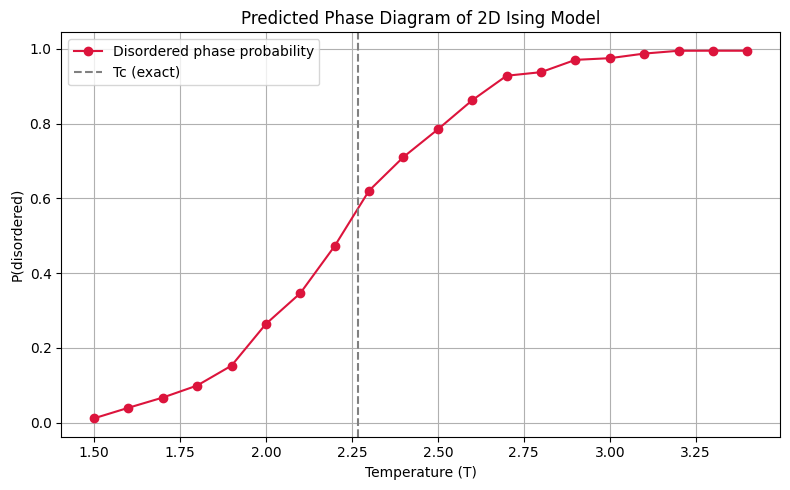

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import random
import os

# ---------------- Model Definition ----------------
class IsingCNN(nn.Module):
    def __init__(self, L):
        super(IsingCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * (L // 4) * (L // 4), 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

# ---------------- Dataset Class ----------------
class IsingDataset(Dataset):
    def __init__(self, configs, labels):
        self.X = torch.tensor(configs, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ---------------- Data Generator ----------------
def generate_ising_data(L, T, mc_steps=1000):
    spins = np.random.choice([-1, 1], size=(L, L))
    for _ in range(mc_steps):
        x, y = random.randint(0, L-1), random.randint(0, L-1)
        delta_E = 2 * spins[x, y] * (
            spins[(x+1)%L, y] + spins[(x-1)%L, y] + spins[x, (y+1)%L] + spins[x, (y-1)%L]
        )
        if delta_E < 0 or random.random() < np.exp(-delta_E / T):
            spins[x, y] *= -1
    return spins

# ---------------- Training ----------------
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(X)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                preds = model(X).argmax(dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        print(f"Validation Accuracy: {100 * correct / total:.2f}%\n")

# ---------------- Phase Prediction ----------------
def get_disorder_probs(model, temp_loaders):
    device = next(model.parameters()).device
    temps, probs = [], []
    model.eval()

    with torch.no_grad():
        for T, loader in temp_loaders:
            batch_probs = []
            for X, _ in loader:
                X = X.to(device)
                out = F.softmax(model(X), dim=1)[:, 1]  # P(disordered)
                batch_probs.append(out.cpu().numpy())
            probs.append(np.concatenate(batch_probs).mean())
            temps.append(T)

    return np.array(temps), np.array(probs)

# ---------------- Helpers ----------------
def create_temp_data_loaders(configs_by_T, batch_size=64):
    loaders = []
    for T, configs in configs_by_T.items():
        dataset = IsingDataset(configs, labels=np.zeros(len(configs)))
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        loaders.append((T, loader))
    return sorted(loaders)

def plot_phase_diagram(temps, probs, save_path=None):
    plt.figure(figsize=(8, 5))
    plt.plot(temps, probs, 'o-', color='crimson', label="Disordered phase probability")
    plt.axvline(2.269, color='gray', linestyle='--', label="Tc (exact)")
    plt.xlabel("Temperature (T)")
    plt.ylabel("P(disordered)")
    plt.title("Predicted Phase Diagram of 2D Ising Model")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

# ---------------- Main Script ----------------
if __name__ == "__main__":
    # --- Parameters ---
    L = 16
    N_TRAIN = 5000
    N_PER_T = 200
    EPOCHS = 10
    BATCH = 64

    T_ordered = 1.0
    T_disordered = 3.5

    print("Generating training data...")
    ordered = [generate_ising_data(L, T_ordered) for _ in range(N_TRAIN)]
    disordered = [generate_ising_data(L, T_disordered) for _ in range(N_TRAIN)]
    configs = np.array(ordered + disordered)
    labels = np.array([0]*N_TRAIN + [1]*N_TRAIN)

    dataset = IsingDataset(configs, labels)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH)

    model = IsingCNN(L)
    train_model(model, train_loader, val_loader, epochs=EPOCHS)

    print("Generating configs for phase diagram...")
    T_range = np.arange(1.5, 3.5, 0.1)
    configs_by_T = {T: [generate_ising_data(L, T) for _ in range(N_PER_T)] for T in T_range}
    loaders = create_temp_data_loaders(configs_by_T, batch_size=BATCH)

    print("Predicting disorder probabilities...")
    temps, probs = get_disorder_probs(model, loaders)

    output_path = "/mnt/data/phase_diagram.png"
    plot_phase_diagram(temps, probs, save_path=output_path)
    print(f"Phase diagram saved to: {output_path}")
